# Final Project AAI-510-IN3-Team 1 — Credit Card Fraud Detection Using Machine Learning

**Business use case:** Credit Card Fraud Detection  
**Dataset:** Kaggle — `mlg-ulb/creditcardfraud`  
**Target variable:** `Class` where `1 = Fraud` and `0 = Genuine transaction`

This notebook is organized as a technical report for the ML engineering committee. It includes business understanding, data understanding, data preparation, feature engineering, model comparison, evaluation, and deployment planning.

> **Security note:** Do not commit Kaggle API keys, `kaggle.json`, raw data, or trained model artifacts to GitHub.

## 1. Problem Statement and Business Justification

Credit card fraud is a rare but high-impact event. A payment provider needs to identify fraudulent transactions quickly while minimizing unnecessary blocks on genuine customers.

The business objective is to build a machine learning model that assigns a fraud-risk score to each transaction. The model should help fraud operations:

- Catch more fraudulent transactions before financial loss occurs.
- Reduce customer harm from unauthorized purchases.
- Avoid excessive false alarms that block legitimate purchases.
- Prioritize high-risk transactions for step-up verification or manual review.

Because fraud is extremely rare, **accuracy alone is not a reliable success metric**. We evaluate models using fraud recall, precision, F1-score, ROC-AUC, PR-AUC, confusion matrix, and threshold-based business tradeoffs.

In [ ]:
# Optional: install required packages in Google Colab or a fresh notebook environment
# Run this cell only if these packages are missing.

# !pip install kaggle scikit-learn pandas numpy matplotlib joblib

In [2]:
from pathlib import Path
import pandas as pd

csv_path = Path(r"C:\\Users\\s_nzh\Downloads\\creditcard_dataset\\creditcard.csv")

assert csv_path.exists(), f"creditcard.csv not found at {csv_path}"

df = pd.read_csv(csv_path)

print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Import Libraries and Load Data

In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
import joblib

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

csv_path = Path("C:\\Users\\s_nzh\Downloads\\creditcard_dataset\\creditcard.csv")
df = pd.read_csv(csv_path)

print("Dataset shape:", df.shape)
display(df.head())

<>:38: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\D'
C:\Users\s_nzh\AppData\Local\Temp\ipykernel_15612\719291404.py:38: SyntaxWarning: invalid escape sequence '\D'
  csv_path = Path("C:\\Users\\s_nzh\Downloads\\creditcard_dataset\\creditcard.csv")


Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


## 4. Data Understanding

The dataset has one row per transaction. The feature columns are:

- `Time`: seconds elapsed between the current transaction and the first transaction in the dataset.
- `Amount`: transaction amount.
- `V1` to `V28`: anonymized PCA-transformed numerical features.
- `Class`: response variable; `1 = fraud`, `0 = genuine`.

Since most predictors are PCA-transformed, we should avoid assigning business meaning to individual `V` columns. They are useful predictive signals but not directly interpretable business fields.

In [4]:
# Basic data audit

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn data types:")
display(df.dtypes.value_counts())

print("\nMissing values by column:")
missing = df.isna().sum().sort_values(ascending=False)
display(
    missing[missing > 0] 
    if (missing > 0).any() 
    else pd.Series({"No missing values": 0})
)

print("\nDuplicate row count:", df.duplicated().sum())

print("\nTarget distribution:")
target_counts = df["Class"].value_counts().rename(index={0: "Genuine", 1: "Fraud"})
display(target_counts)

fraud_rate = df["Class"].mean() * 100
print(f"\nFraud rate: {fraud_rate:.4f}%")

Rows: 284807
Columns: 31

Column data types:


float64    30
int64       1
Name: count, dtype: int64


Missing values by column:


No missing values    0
dtype: int64


Duplicate row count: 1081

Target distribution:


Class
Genuine    284315
Fraud         492
Name: count, dtype: int64


Fraud rate: 0.1727%


### Plot 1 — Class Distribution

This plot shows the extreme imbalance in the target variable. Fraud is rare, so a naive model can appear highly accurate while failing to detect fraud.

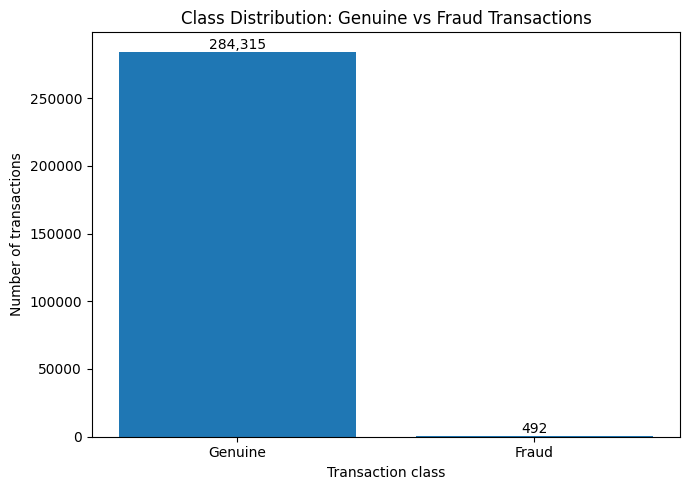

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
target_counts = df["Class"].map({0: "Genuine", 1: "Fraud"}).value_counts()
ax.bar(target_counts.index, target_counts.values)
ax.set_title("Class Distribution: Genuine vs Fraud Transactions")
ax.set_xlabel("Transaction class")
ax.set_ylabel("Number of transactions")

for i, value in enumerate(target_counts.values):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### Plot 2 — Fraud Share

The fraud slice is intentionally tiny. This business problem should be evaluated using fraud-focused metrics such as recall, precision, and PR-AUC, not accuracy alone.

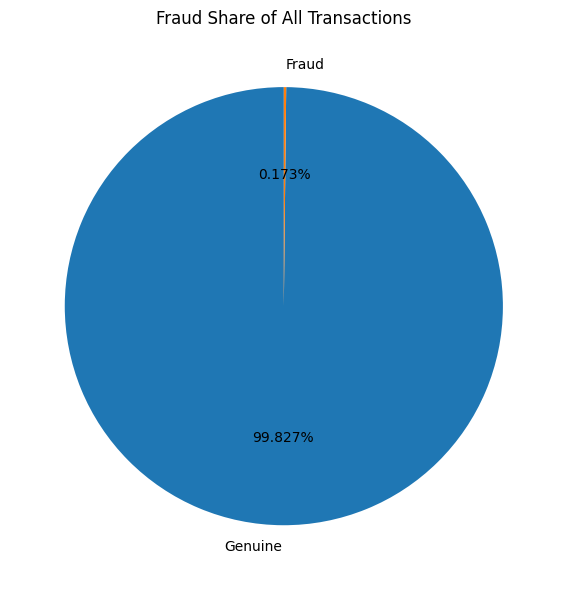

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
labels = ["Genuine", "Fraud"]
sizes = [int((df["Class"] == 0).sum()), int((df["Class"] == 1).sum())]

ax.pie(
    sizes,
    labels=labels,
    autopct=lambda pct: f"{pct:.3f}%",
    startangle=90
)
ax.set_title("Fraud Share of All Transactions")
plt.tight_layout()
plt.show()

### Plot 3 — Transaction Amount Distribution

Transaction amounts are usually skewed. We inspect both raw amount and log-transformed amount.

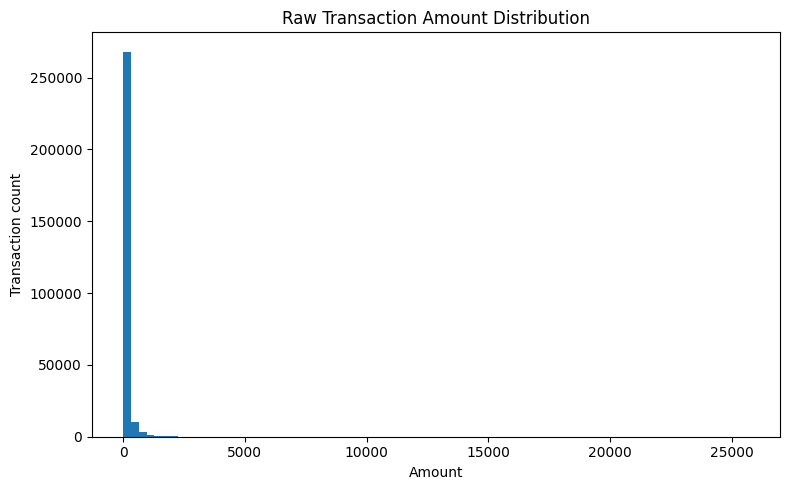

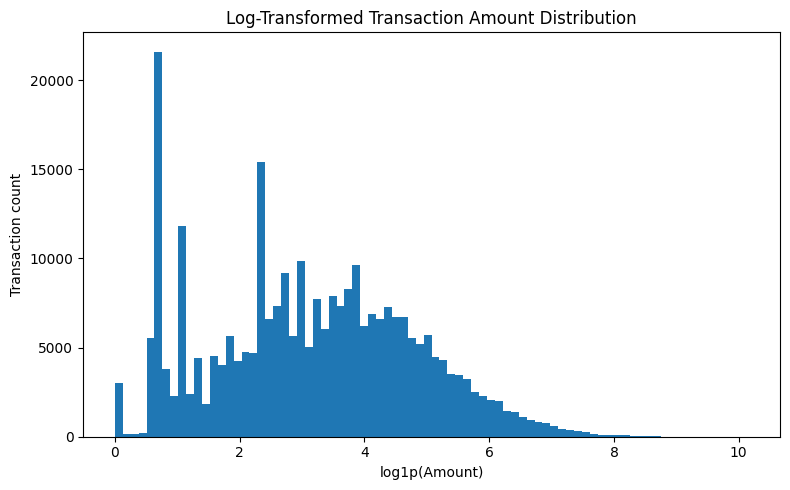

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["Amount"], bins=80)
ax.set_title("Raw Transaction Amount Distribution")
ax.set_xlabel("Amount")
ax.set_ylabel("Transaction count")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(np.log1p(df["Amount"]), bins=80)
ax.set_title("Log-Transformed Transaction Amount Distribution")
ax.set_xlabel("log1p(Amount)")
ax.set_ylabel("Transaction count")
plt.tight_layout()
plt.show()

### Plot 4 — Amount by Class

This plot compares transaction amount patterns between genuine and fraudulent transactions. Amount alone is usually not enough to detect fraud, but it can contribute to risk scoring.

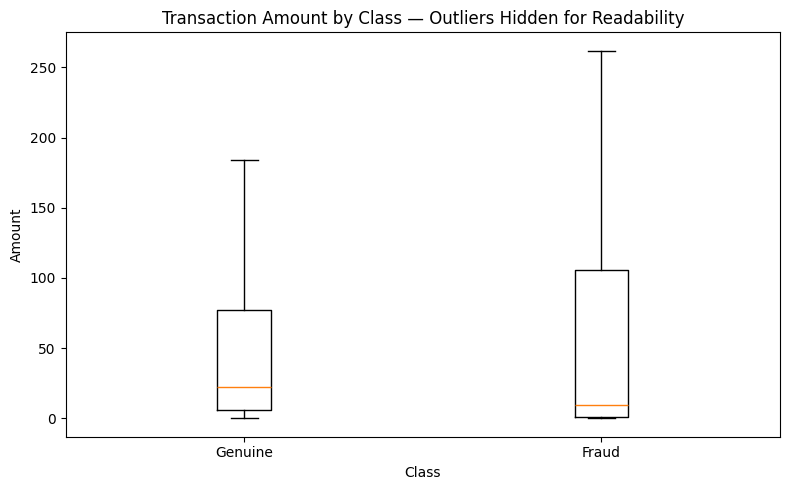

Amount summary by class:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
Genuine,"284,315.0000",88.2910,250.1051,0.0000,5.6500,22.0000,77.0500,"25,691.1600"
Fraud,492.0000,122.2113,256.6833,0.0000,1.0000,9.2500,105.8900,"2,125.8700"


In [8]:
amount_by_class = [
    df.loc[df["Class"] == 0, "Amount"],
    df.loc[df["Class"] == 1, "Amount"]
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(amount_by_class, labels=["Genuine", "Fraud"], showfliers=False)
ax.set_title("Transaction Amount by Class — Outliers Hidden for Readability")
ax.set_xlabel("Class")
ax.set_ylabel("Amount")
plt.tight_layout()
plt.show()

print("Amount summary by class:")
display(df.groupby("Class")["Amount"].describe().rename(index={0: "Genuine", 1: "Fraud"}))

### Plot 5 — Transaction Time Pattern

`Time` is measured in seconds from the first transaction. We convert it into an approximate hour-of-day signal for exploration.

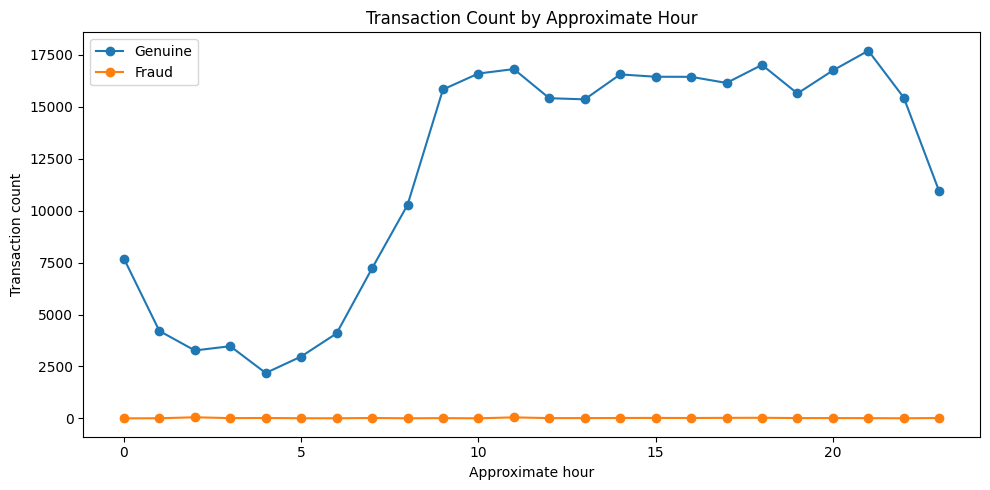

Class,Genuine,Fraud
Hour,,
0,7689,6
1,4210,10
2,3271,57
3,3475,17
4,2186,23


In [9]:
df["Hour"] = ((df["Time"] // 3600) % 24).astype(int)

hourly = df.groupby(["Hour", "Class"]).size().unstack(fill_value=0)
hourly = hourly.rename(columns={0: "Genuine", 1: "Fraud"})

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hourly.index, hourly["Genuine"], marker="o", label="Genuine")
ax.plot(hourly.index, hourly["Fraud"], marker="o", label="Fraud")
ax.set_title("Transaction Count by Approximate Hour")
ax.set_xlabel("Approximate hour")
ax.set_ylabel("Transaction count")
ax.legend()
plt.tight_layout()
plt.show()

display(hourly.head())

### Plot 6 — Correlation with Target

The `V` features are PCA-transformed, so we should not over-interpret them. However, correlation can still help us identify variables that may have predictive value.

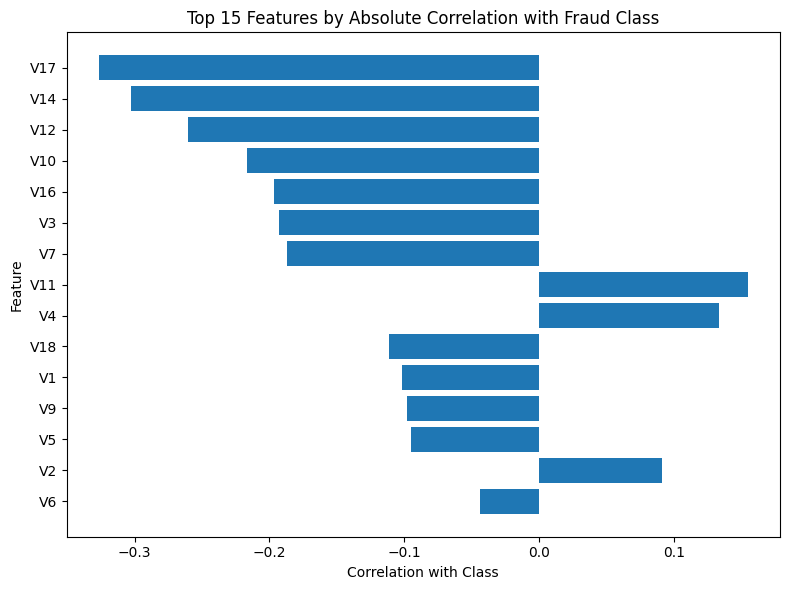

,correlation_with_fraud
V17,-0.3265
V14,-0.3025
V12,-0.2606
V10,-0.2169
V16,-0.1965
V3,-0.1930
V7,-0.1873
V11,0.1549
V4,0.1334
V18,-0.1115


In [10]:
corr_with_target = (
    df.corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

top_corr = corr_with_target.head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_corr.index[::-1], top_corr.values[::-1])
ax.set_title("Top 15 Features by Absolute Correlation with Fraud Class")
ax.set_xlabel("Correlation with Class")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

display(top_corr.to_frame("correlation_with_fraud"))

## 5. Data Preparation and Feature Engineering

Preparation decisions:

- Keep `V1–V28` because they are already numerical PCA features.
- Create `LogAmount` to reduce skew in transaction amount.
- Create `Hour` from `Time` as a simple timing signal.
- Use stratified train-test split to preserve the rare fraud ratio.
- Scale non-PCA fields: `Time`, `Amount`, `LogAmount`, and `Hour`.
- Do not resample before train-test split to avoid data leakage.

In [11]:
# Feature engineering

import numpy as np
from sklearn.model_selection import train_test_split

model_df = df.copy()

# Create log-transformed amount to reduce skew
model_df["LogAmount"] = np.log1p(model_df["Amount"])

# Convert Time from seconds into approximate hour of day
model_df["Hour"] = ((model_df["Time"] // 3600) % 24).astype(int)

target = "Class"
features = [c for c in model_df.columns if c != target]

X = model_df[features]
y = model_df[target]

# Stratified split is important because fraud cases are very rare
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

print()
print("Training class rate:")
display(
    y_train
    .value_counts(normalize=True)
    .rename(index={0: "Genuine", 1: "Fraud"})
)

print()
print("Test class rate:")
display(
    y_test
    .value_counts(normalize=True)
    .rename(index={0: "Genuine", 1: "Fraud"})
)

Training shape: (227845, 32)
Test shape: (56962, 32)

Training class rate:


Class
Genuine   0.9983
Fraud     0.0017
Name: proportion, dtype: float64


Test class rate:


Class
Genuine   0.9983
Fraud     0.0017
Name: proportion, dtype: float64

## 6. Modeling

We compare a simple baseline against supervised learning models covered in the course.

Models:
1. Dummy classifier — baseline.
2. Logistic regression — fast, transparent benchmark.
3. Decision tree — interpretable but can overfit.
4. Random forest — ensemble model with better stability.
5. Histogram gradient boosting — strong tabular model candidate.

Because fraud is rare, models that support `class_weight='balanced'` are configured to pay more attention to the minority fraud class.

In [12]:
# Preprocessor
# V1-V28 are PCA features and are already transformed.
# Time, Amount, LogAmount, and Hour are scaled for models that need scaling.

scale_cols = ["Time", "Amount", "LogAmount", "Hour"]
passthrough_cols = [c for c in X_train.columns if c not in scale_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), scale_cols),
        ("pass", "passthrough", passthrough_cols)
    ],
    remainder="drop"
)

models = {
    "Dummy Baseline": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),
    "Logistic Regression": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=42
        ))
    ]),
    "Decision Tree": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=42
        ))
    ]),
    "Hist Gradient Boosting": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", HistGradientBoostingClassifier(
            max_iter=150,
            learning_rate=0.08,
            max_leaf_nodes=31,
            random_state=42
        ))
    ])
}

print("Models ready:", list(models.keys()))

Models ready: ['Dummy Baseline', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'Hist Gradient Boosting']


In [13]:
# Train and evaluate models

def get_scores(model, X):
    """Return probability-like fraud scores for ROC/PR evaluation."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    return model.predict(X)

results = []
trained_models = {}

for name, pipe in models.items():
    print(f"Training: {name}")
    
    if name == "Hist Gradient Boosting":
        # HistGradientBoostingClassifier may not support class_weight in all sklearn versions.
        # We pass sample weights to focus more on rare fraud cases.
        sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
        pipe.fit(X_train, y_train, model__sample_weight=sample_weight)
    else:
        pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_score = get_scores(pipe, X_test)
    
    result = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_fraud": precision_score(y_test, y_pred, zero_division=0),
        "recall_fraud": recall_score(y_test, y_pred, zero_division=0),
        "f1_fraud": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc_avg_precision": average_precision_score(y_test, y_score)
    }
    results.append(result)
    trained_models[name] = pipe

metrics_df = pd.DataFrame(results).sort_values(
    by=["pr_auc_avg_precision", "recall_fraud"],
    ascending=False
).reset_index(drop=True)

display(metrics_df)

Training: Dummy Baseline
Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: Hist Gradient Boosting


,model,accuracy,precision_fraud,recall_fraud,f1_fraud,roc_auc,pr_auc_avg_precision
0,Random Forest,0.9994,0.8081,0.8163,0.8122,0.9733,0.8582
1,Logistic Regression,0.9736,0.0563,0.9082,0.1060,0.9733,0.7225
2,Hist Gradient Boosting,0.9959,0.2834,0.8878,0.4296,0.9631,0.7202
3,Decision Tree,0.9762,0.0595,0.8673,0.1114,0.9123,0.5957
4,Dummy Baseline,0.9983,0.0000,0.0000,0.0000,0.5000,0.0017


### Plot 7 — Model Comparison

PR-AUC / Average Precision is especially important because the fraud class is extremely rare.

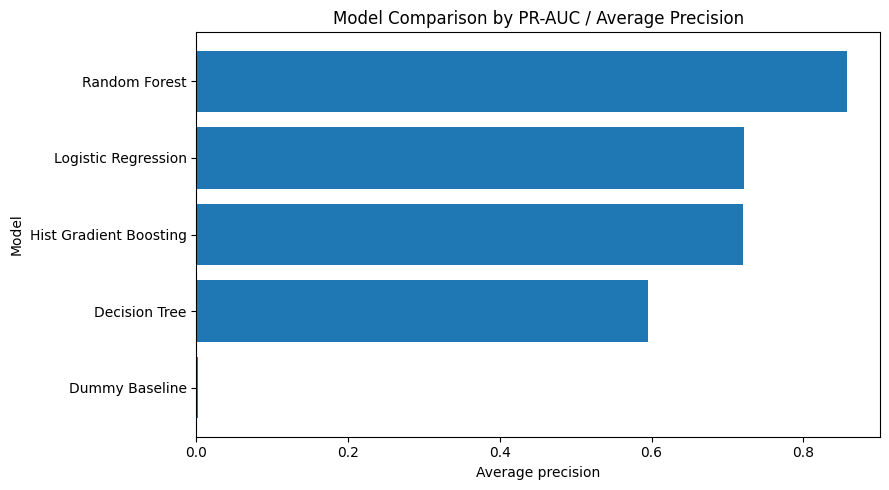

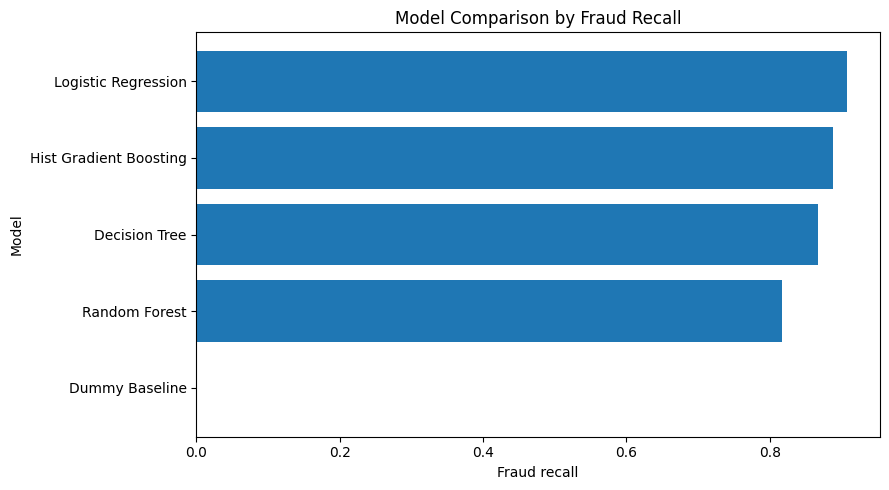

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = metrics_df.sort_values("pr_auc_avg_precision", ascending=True)
ax.barh(plot_df["model"], plot_df["pr_auc_avg_precision"])
ax.set_title("Model Comparison by PR-AUC / Average Precision")
ax.set_xlabel("Average precision")
ax.set_ylabel("Model")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = metrics_df.sort_values("recall_fraud", ascending=True)
ax.barh(plot_df["model"], plot_df["recall_fraud"])
ax.set_title("Model Comparison by Fraud Recall")
ax.set_xlabel("Fraud recall")
ax.set_ylabel("Model")
plt.tight_layout()
plt.show()

## 7. Select Best Model

The recommended model should balance:
- High fraud recall to catch more fraud.
- Reasonable precision to avoid overwhelming fraud analysts.
- Strong PR-AUC for rare-event detection.
- Operational feasibility and monitoring readiness.

This notebook selects the model with the highest PR-AUC as the default candidate. You can change the selection rule if the business prioritizes recall or analyst workload differently.

In [1]:
best_model_name = metrics_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print(f"Selected model based on highest PR-AUC: {best_model_name}")

y_pred_best = best_model.predict(X_test)
y_score_best = get_scores(best_model, X_test)

print("Classification report:")
print(classification_report(y_test, y_pred_best, target_names=["Genuine", "Fraud"], zero_division=0))

NameError: name 'metrics_df' is not defined

### Plot 8 — Confusion Matrix

This matrix translates model performance into operational outcomes:

- True positives: fraud correctly flagged.
- False positives: genuine transactions incorrectly flagged.
- False negatives: fraud missed by the model.
- True negatives: genuine transactions correctly approved.

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Genuine", "Fraud"])
disp.plot(ax=ax, values_format=",d")
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

### Plot 9 — ROC Curve and Precision-Recall Curve

For fraud detection, the Precision-Recall curve is usually more informative than ROC because fraud is extremely rare.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_score_best, ax=ax)
ax.set_title(f"ROC Curve — {best_model_name}")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_score_best, ax=ax)
ax.set_title(f"Precision-Recall Curve — {best_model_name}")
plt.tight_layout()
plt.show()

## 8. Threshold Tuning for Business Use

The default classification threshold of 0.50 may not be best for fraud detection. A fraud team may prefer a lower threshold to catch more fraud, while controlling false alerts based on review capacity.

This section compares precision, recall, and F1 across thresholds.

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_score_best)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)

# thresholds has one fewer value than precision/recall
threshold_df = pd.DataFrame({
    "threshold": np.append(thresholds, 1.0),
    "precision": precision,
    "recall": recall,
    "f1": f1_scores
})

plot_threshold_df = threshold_df[(threshold_df["threshold"] >= 0.001) & (threshold_df["threshold"] <= 0.999)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(plot_threshold_df["threshold"], plot_threshold_df["precision"], label="Precision")
ax.plot(plot_threshold_df["threshold"], plot_threshold_df["recall"], label="Recall")
ax.plot(plot_threshold_df["threshold"], plot_threshold_df["f1"], label="F1")
ax.set_title(f"Threshold Tuning — {best_model_name}")
ax.set_xlabel("Fraud score threshold")
ax.set_ylabel("Metric value")
ax.legend()
plt.tight_layout()
plt.show()

best_f1_row = threshold_df.iloc[threshold_df["f1"].idxmax()]
print("Best threshold by F1:")
display(best_f1_row.to_frame().T)

### Business Threshold Scenario

This section shows what happens if the business reviews the top-risk transactions. Instead of using a fixed probability threshold, fraud operations may choose a review capacity such as top 1%, top 2%, or top 5% highest-risk transactions.

In [ ]:
test_results = X_test.copy()
test_results["actual_class"] = y_test.values
test_results["fraud_score"] = y_score_best
test_results = test_results.sort_values("fraud_score", ascending=False).reset_index(drop=True)

review_rates = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05]
scenario_rows = []

total_fraud = int((test_results["actual_class"] == 1).sum())

for rate in review_rates:
    n_review = max(1, int(len(test_results) * rate))
    reviewed = test_results.head(n_review)
    captured_fraud = int((reviewed["actual_class"] == 1).sum())
    scenario_rows.append({
        "review_rate": rate,
        "transactions_reviewed": n_review,
        "fraud_captured": captured_fraud,
        "fraud_capture_rate": captured_fraud / total_fraud if total_fraud else 0,
        "alert_precision": captured_fraud / n_review
    })

scenario_df = pd.DataFrame(scenario_rows)
display(scenario_df)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(scenario_df["review_rate"] * 100, scenario_df["fraud_capture_rate"] * 100, marker="o")
ax.set_title("Fraud Captured by Review Queue Size")
ax.set_xlabel("Top-risk transactions reviewed (%)")
ax.set_ylabel("Fraud captured (%)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(scenario_df["review_rate"] * 100, scenario_df["alert_precision"] * 100, marker="o")
ax.set_title("Alert Precision by Review Queue Size")
ax.set_xlabel("Top-risk transactions reviewed (%)")
ax.set_ylabel("Fraud rate inside reviewed queue (%)")
plt.tight_layout()
plt.show()

## 9. Feature Importance

For tree-based models, feature importance can help identify which signals influenced the model. Since most features are PCA components, we should not over-interpret the business meaning of `V1–V28`.

Permutation importance is model-agnostic but can take time. This cell uses a sample of the test data for speed.

In [ ]:
# Permutation importance on a sample for speed
sample_size = min(10000, len(X_test))
X_perm = X_test.sample(sample_size, random_state=42)
y_perm = y_test.loc[X_perm.index]

perm = permutation_importance(
    best_model,
    X_perm,
    y_perm,
    scoring="average_precision",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_perm.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(importance_df.head(15))

fig, ax = plt.subplots(figsize=(8, 6))
top_importance = importance_df.head(15).sort_values("importance_mean", ascending=True)
ax.barh(top_importance["feature"], top_importance["importance_mean"])
ax.set_title(f"Top 15 Permutation Importances — {best_model_name}")
ax.set_xlabel("Decrease in average precision when shuffled")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## 10. Save Artifacts

The selected model and metrics are saved for reproducibility. These artifacts should generally not be committed to GitHub unless the instructor specifically asks for them and the file size is acceptable.

In [ ]:
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

model_path = ARTIFACT_DIR / "credit_card_fraud_best_model.joblib"
metrics_path = ARTIFACT_DIR / "credit_card_fraud_model_metrics.csv"
scenario_path = ARTIFACT_DIR / "credit_card_fraud_review_queue_scenarios.csv"

joblib.dump(best_model, model_path)
metrics_df.to_csv(metrics_path, index=False)
scenario_df.to_csv(scenario_path, index=False)

print("Saved model:", model_path)
print("Saved metrics:", metrics_path)
print("Saved review queue scenarios:", scenario_path)

## 11. Deployment Plan

This project does not require a full standalone deployment, but the deployment plan should be realistic.

Recommended deployment type:
- **Primary:** Real-time or near-real-time scoring during transaction authorization.
- **Secondary:** Batch scoring for retrospective monitoring, fraud investigation, and model validation.

Production design:
1. Transaction arrives from payment authorization system.
2. Feature pipeline prepares the model input.
3. Model scoring API returns a fraud-risk score.
4. Decision engine maps score into action:
   - Low risk: approve.
   - Medium risk: step-up verification.
   - High risk: manual review or temporary block.
5. Logs are saved for audit, monitoring, and retraining.
6. Monitoring tracks fraud recall, precision, false positives, latency, drift, and customer complaints.

Important production considerations:
- Real-time scoring needs low latency and high availability.
- A fallback rule engine or previous model version should be available if the scoring service fails.
- Fraud patterns change, so model drift monitoring and periodic retraining are required.
- Thresholds should be business-controlled and reviewed regularly.
- Model version, data version, threshold version, and decision logs should be traceable.

## 12. GitHub Collaboration and Version Control

Required GitHub practices:
- Host notebooks, source code, README, and requirements file in GitHub.
- Do not commit raw data, Kaggle API keys, `kaggle.json`, model artifacts, or secrets.
- Use `.gitignore` to exclude:
  - `data/`
  - `artifacts/`
  - `.env`
  - `kaggle.json`
  - `*.joblib`
- Use branches for workstreams:
  - `eda`
  - `feature-engineering`
  - `modeling`
  - `slides`
- Use pull requests so changes are reviewed before merging.
- Tag final release before submission.

Example repository structure:

```text
credit-card-fraud-final-project/
├── notebooks/
│   └── Final Project SectionX-Team 1 - Credit Card Fraud.ipynb
├── src/
│   ├── features.py
│   ├── train.py
│   └── evaluate.py
├── slides/
│   └── Final Project SectionX-Team 1.pptx
├── requirements.txt
├── README.md
└── .gitignore
```

## 13. Discussion and Conclusion

The credit card fraud dataset is a strong business ML use case because fraud is rare, high impact, and time-sensitive. The project shows why raw accuracy is not sufficient and why fraud-focused metrics are required.

The recommended solution is not blind automatic blocking. The better business approach is a fraud-risk scoring system that supports:
- automatic approval for low-risk transactions,
- step-up authentication for medium-risk transactions,
- manual review or temporary block for high-risk transactions.

The final model should be selected based on validation PR-AUC, fraud recall, precision, and review queue impact. The deployment should begin with shadow scoring, then a controlled pilot, and finally a monitored production rollout.